In [91]:
#Initializing libraries, functions
import numpy as np
import matplotlib.pyplot as plt

def leastSquares(x,y):
    n = len(x)
    
    # Minimizing residuals
    m = (n*(np.sum(x*y))-(np.sum(x)*np.sum(y)))/(n*np.sum(x**2)-(np.sum(x)**2))
    
    # Fitting line
    c = (np.sum(y)-m*(np.sum(x)))/n
    
    # Fitting to a continuous x variable
    xf = np.arange(1,np.max(gdpXvals)+1)
    yf = m*xf + c
    
    coeffs = [c, m]
    
    return xf, yf, coeffs

def polyFit(x, y, degree):
    x = list(x)
    y = list(y)
    n = len(x)
    m = degree + 1
    
    #scaling
    x = (x - np.mean(x)) / (np.std(x))

    # Vandermonde matrix
    V = [[x[i]**j for j in range(m)] for i in range(n)]

    # V^T@V
    VT_V = [[0]*m for _ in range(m)]
    for i in range(m):
        for j in range(m):
            for k in range(n):
                VT_V[i][j] += V[k][i] * V[k][j]

    # Compute V^T@y
    VT_y = [0]*m
    for i in range(m):
        for k in range(n):
            VT_y[i] += V[k][i] * y[k]

    # (VT_V)c = VT_y
    c = gaussian_elimination(VT_V, VT_y)

    # Generate smooth curve
    xf = np.linspace(min(x), max(x), 200)
    yf = []

    # Generate y arra
    for xi in xf:
        yi = 0
        for j in range(m):
            yi += c[j] * (xi ** j)
        yf.append(yi)
    cond = np.linalg.cond(VT_V)
    return xf, np.array(yf), c, cond

def cubicSpline(x, y, nat):
    n = len(x)
    h = np.diff(x)

    # Build system
    a = h[:-1]
    b = 2 * (h[:-1] + h[1:])
    c = h[1:]
    d = 6 * ((y[2:] - y[1:-1]) / h[1:] - (y[1:-1] - y[:-2]) / h[:-1])

    # Tridiagonal system (Thomas algorithm)
    cp = np.zeros(n-2)
    dp = np.zeros(n-2)

    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]

    for i in range(1, n-2):
        denom = b[i] - a[i-1] * cp[i-1]
        cp[i] = c[i] / denom
        dp[i] = (d[i] - a[i-1] * dp[i-1]) / denom
        
    # Second degree condition initiailization

    M = np.zeros(n)
    M[-2] = dp[-1]

    for i in range(n-4, -1, -1):
        M[i+1] = dp[i] - cp[i] * M[i+2]

    if nat:
        # Natural boundary conditions
        M[0] = 0
        M[-1] = 0

    # Evaluate spline
    xf = np.linspace(min(x), max(x), 200)
    yf = []

    for xi in xf:
        i = np.searchsorted(x, xi) - 1
        i = np.clip(i, 0, n-2)

        hi = x[i+1] - x[i]
        dx1 = x[i+1] - xi
        dx2 = xi - x[i]

        S = (
            (M[i] * dx1**3) / (6 * hi) +
            (M[i+1] * dx2**3) / (6 * hi) +
            (y[i] / hi - M[i] * hi / 6) * dx1 +
            (y[i+1] / hi - M[i+1] * hi / 6) * dx2
        )
        yf.append(S)

    return xf, np.array(yf)

# Helper Functions
# Gaussian elimination
def gaussian_elimination(A, b):
    n = len(b)

    # Forward elimination
    for i in range(n):
        # Pivot
        max_row = max(range(i, n), key=lambda r: abs(A[r][i]))
        A[i], A[max_row] = A[max_row], A[i]
        b[i], b[max_row] = b[max_row], b[i]

        for j in range(i+1, n):
            factor = A[j][i] / A[i][i]
            for k in range(i, n):
                A[j][k] -= factor * A[i][k]
            b[j] -= factor * b[i]

    # Back substitution
    x = [0]*n
    for i in range(n-1, -1, -1):
        s = sum(A[i][j] * x[j] for j in range(i+1, n))
        x[i] = (b[i] - s) / A[i][i]

    return x

# Helper Functions

def rmse(y_true, x_true, x_fit, y_fit):
    y_pred = np.interp(x_true, x_fit, y_fit)
    residuals = y_true - y_pred
    return np.sqrt(np.mean(residuals**2))

def plot_residuals(x_true, y_true, x_fit, y_fit, title):
    y_pred = np.interp(x_true, x_fit, y_fit)
    residuals = y_true - y_pred
    
    plt.scatter(x_true, residuals)
    plt.title(title)
    plt.xlabel("Quarter Index")
    plt.ylabel("Residuals")
    plt.show()

In [92]:
# Initializing GDP Growth Rate Array
gdpGrowth = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])
gdpXvals = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56])

INTRODUCTION

Above I have developed 3 different functions which develop a fitted line for data based on linear least squares, cubic spline, and polynomial fitting. These 3 different data fitting strategies are solved differently. Linear least squares is solved by minimizing squared residuals, cubic spline is solved by piecewise Thomas algorithm and the polynomial fit uses a vandermonde matrix and the coefficients from solving it. The dataset consists of U.S. GDP Growth Rates from 2010 Q1 to 2023 Q4 taken from the U.S. Bureau of Economic Analysis (BEA). This dataset most notably contains the effect on the GDP from covid and it's recovery which will help determine which fitting method is most appropriate for dynamic systems. 

PART A

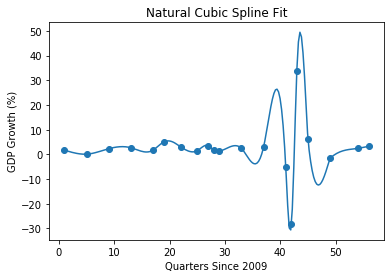

In [93]:
# Natural Cubic Spline
plt.scatter(gdpXvals, gdpGrowth)
x, y = cubicSpline(gdpXvals, gdpGrowth, True)
plt.plot(x,y)
plt.title("Natural Cubic Spline Fit")
plt.xlabel("Quarters Since 2009")
plt.ylabel("GDP Growth (%)")
plt.show()


1) The system of equations I'm asked to solve is the tridiagonal system using the Thomas Algorithm. It consists of solving the second derivative for all the piece wise functions inbetween the knots. If there are twenty data points, then I am solving for n-1 second derivatives (19). However, because M0 = M(n-1) due to the boundary conditions of a natural cubic spline, I am only solving for 18 unknowns (n-2). The interior knots must be continuous up to the second order deriviatives, so for example: S1[x]=S2[x], S1'[x]=S2'[x], and S1''[x]=S2''[x]. Natural spline boundary conditions are noted as M0 - M(n-1) = 0.

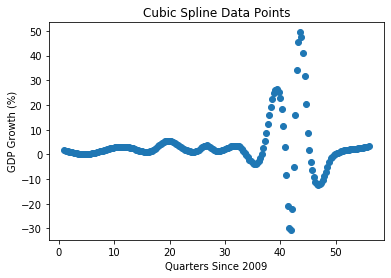

In [94]:
# Cubic Spline

plt.scatter(x, y)
plt.title("Cubic Spline Data Points")
plt.xlabel("Quarters Since 2009")
plt.ylabel("GDP Growth (%)")
plt.show()

2) The interpolant IS smooth and reasonable despite some over shooting in the later quarters it overall encompasses quarterly trends. The regular cubic spline ends up being the same as the natural cubic spline because the spline does not have clamped end conditions. It should be noted that the least reasonable part about this data is the extremely oscillatory data trend due to the cubic spline interpolation. The actual data is likely to be much more rigid and sharp. 

3) The Runge Phenomenon is the problem where a cubic spline fit will oscillate at the edges of an interval when plotting with a high degree. Exact interpolation, such as passing directly through 2020 Q2, can cause the interpolant to look less reasonable and under/over-shoot in certain regions, as seen in the spline. In this case, smoothing splines is still preferable to a weighted least squares approach due to the outliers being opposite in direction and right after each other, the least squares would be unable to capture that oscillatory trend whereas the smoothing splines would, even if it is mildly unreasonable. To combat this phenomenon, it is better to stick with lower degree data interpolation in order to prevent unwanted boundary behavior.

PART B

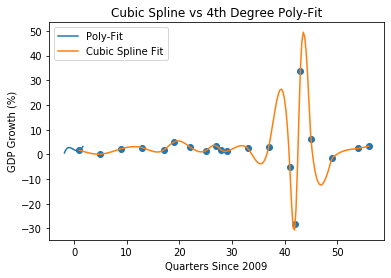

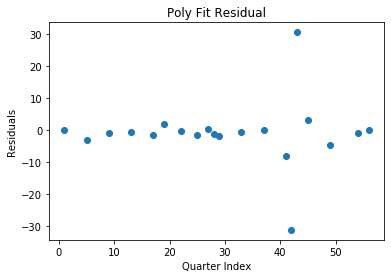

RSME:  10.105227590166471
Condition Number:  229.50801231227365


In [95]:
# Cubic Spline vs 4th Degree Polynomial Fit
plt.scatter(gdpXvals, gdpGrowth)
x1, y1, c, cond = polyFit(gdpXvals, gdpGrowth, 4)
plt.plot(x1,y1, label="Poly-Fit")
x2, y2 = cubicSpline(gdpXvals, gdpGrowth, False)
plt.plot(x2,y2, label="Cubic Spline Fit")
plt.title("Cubic Spline vs 4th Degree Poly-Fit")
plt.legend()
plt.xlabel("Quarters Since 2009")
plt.ylabel("GDP Growth (%)")
plt.show()
plot_residuals(gdpXvals, gdpGrowth, x1, y1, "Poly Fit Residual")
print("RSME: ", rmse(gdpGrowth, gdpXvals, x1, y1))
print("Condition Number: ", cond)

1) The cubic spline overall captures the data trend better due to its ability to represent outliers and system shock/disturbance. The cubic spline is also better at representing specific data points due to it being forced to pass through each data point on the graph, whereas the polynomial fit only gives a rough trend. The polynomial fit was calculated to be 229.5, which is well below the threshold. The tradeoff lies in the approximation being able to represent general averages without being displaced by outliers (such as the covid shock) whereas the cubic spline obviously overshoots the data fitting, however the approximation cannot represent outliers to hardly any accuracy. The inability to handle shock is noted in the covid indices, where residuals reach values of about 30 and -30.

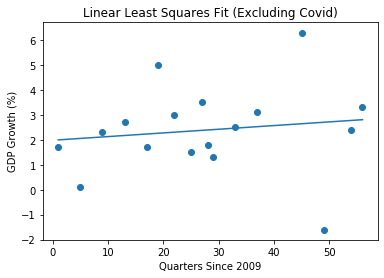

0.014732310498363876


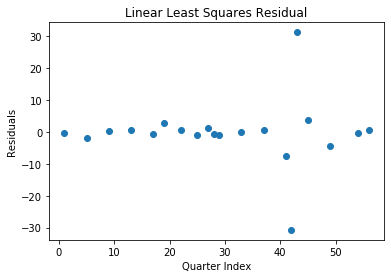

RMSE: 10.056659278883762


In [96]:
# Linear Least Squares Fit for non-Covid data
plt.scatter(gdpXvals[np.r_[0:13, 16:20]], gdpGrowth[np.r_[0:13, 16:20]])
x, y, c = leastSquares(gdpXvals[np.r_[0:13, 16:20]], gdpGrowth[np.r_[0:13, 16:20]])
plt.plot(x,y)
plt.title("Linear Least Squares Fit (Excluding Covid)")
plt.xlabel("Quarters Since 2009")
plt.ylabel("GDP Growth (%)")
plt.show()
print((y[1]-y[0])/(x[1]-x[0]))
plot_residuals(gdpXvals, gdpGrowth, x, y, "Linear Least Squares Residual")
print("RMSE:", rmse(gdpGrowth, gdpXvals, x, y))

2) The slope was found to be around 0.015. The trend does make sense for this specific data because it contains relatively minimal outliers and the data isn't terribly noisy. However, it assumes the lack of the Covid data, which was a significant disturbance to the GDP growth rate and therefore this fitting isn't entirely accurate and doesn't show the full picture. The linear least squares method bosts a similar residual plot as the poly fit, so one isn't necessarily more accurate than the other.

PART C

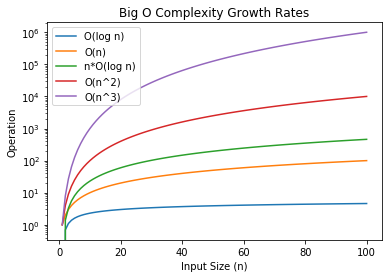

In [97]:
#
n = np.linspace(1, 100, 100)
plt.plot(n, np.log(n), label='O(log n)')
plt.plot(n, n, label='O(n)')
plt.plot(n, n*np.log(n), label='n*O(log n)')
plt.plot(n, n**2, label='O(n^2)')
plt.plot(n, n**3, label='O(n^3)')
plt.yscale('log')

plt.title('Big O Complexity Growth Rates')
plt.xlabel('Input Size (n)')
plt.ylabel('Operation')
plt.legend()
plt.show()

1) I would recommend the cubic spline fitting. It is generally more accurate due to it passing through every knot (data point) and being sensitive to outliers, which is crucial for GDP change analysis during Covid, which the polynomial fit is unable to encompass. The poly-fit is overall more "smooth" however it is too smooth and doesn't encompass GDP change trends year-by-year, leading cubic spline to be most effective for this data set. In addition to this, the cubic spline contains only residuals of zero and an RSME of zero. The poly fit and linear approximation contain non-zero residuals and their residuals peak during covid; they are unable to represent the change in dynamic systems, shock, or recovery. 

2) The Big O Notation is a measure of how execution time of a function increases relative to input size and computations. The Big O notation analysis shows that using strategies like cubic spline interpolation will increase computation time more than the other two methods, however GDP growth rate datasets are generally small enough that it will not significantly effect the ability of the cubic spline method to out perform the other two for this use case.

CONCLUSION

Overall, the cubic spline method performed best overall. It accurately interpolated all the data due to the curve fitting being forced through every knot, and was able to generally show yearly and quarterly trends accurately. The cubic spline was the only method able to capture the shock and recovery of the GDP due to covid and therefore is most truthful to the dataset given. However, excluding the covid data, the linear least squares method shows trends the best (from all the methods that were asked) as seen in part c. Through this project I have learned about the limitations of polynomial fitting in dynamic systems that are snesitive to disturbance and oscillatory behavior. I also learned about high-degree cubic spline behavior and the tradeoff in data fitting between "reasonability" and accurate data-interpretation and curve over-shooting.